<a href="https://colab.research.google.com/github/AlejoCNYT/Curso_CENDES/blob/main/notebook_1_curso_extension(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook exploratorio para análisis de datos usando Ptython

---
_M.Sc. Johan Sánchez Torres_

---

# 1. Librerías.

In [ ]:
# Paquetes que no vienen preinstalados en Colab
!pip install pingouin pyjanitor missingno statsmodels --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.1/277.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.5 MB/s eta 0:00:00


In [ ]:
# ── Manipulación de datos ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
import matplotlib.ticker as mtick


# ── Estadística descriptiva e inferencial ──────────────────────────
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg

# ── Machine learning / preprocesamiento ───────────────────────────
from sklearn import preprocessing, decomposition, cluster
from sklearn.model_selection import train_test_split

# ── Limpieza de datos ──────────────────────────────────────────────
#import pyjanitor

ModuleNotFoundError: No module named 'pingouin'

In [ ]:
# darkgrid  → fondo gris + rejilla (exploración)
# whitegrid → fondo blanco + rejilla (presentaciones)
# dark      → fondo gris, sin rejilla
# white     → blanco limpio, sin rejilla
# ticks     → solo marcas en ejes (publicaciones)

sns.set_style("whitegrid")

# Control fino con rc dict
sns.set_style("whitegrid", {
    "axes.facecolor":    "#FAFAFA",
    "grid.color":        "#E8E8E8",
    "grid.linestyle":   "--",
    "grid.linewidth":    0.5,
    "axes.edgecolor":   "#CCCCCC",
    "axes.linewidth":    0.8,
    "axes.spines.top":  False,
    "axes.spines.right":False,
})


# 2. Análisis exploratorio de datos (EDA)

El análisis exploratorio de datos (EDA, por sus siglas en inglés) constituye una etapa fundamental en cualquier proyecto de ciencia de datos, ya que permite obtener una comprensión inicial del conjunto de datos antes de aplicar técnicas de modelado o inferencia estadística. En esta sección se examinan las propiedades estructurales y estadísticas del dataset mediante los siguientes procedimientos:

- **Creación del dataframe:** se carga el conjunto de datos en un objeto `DataFrame` de pandas para facilitar su manipulación y análisis.
- **Visualización de observaciones:** se inspeccionan las primeras y últimas filas del dataset con el fin de obtener una vista preliminar de su contenido.
- **Dimensiones del dataset:** se determina el número de filas (observaciones) y columnas (variables) que conforman el conjunto de datos.
- **Tipos de datos por variable:** se revisa el tipo de dato asignado a cada columna (`int`, `float`, `object`, `datetime`, etc.) para verificar su coherencia con la naturaleza de cada variable.
- **Identificación de datos faltantes:** se detecta la presencia de valores nulos o ausentes (`NaN`) que puedan comprometer la calidad del análisis o requerir un tratamiento previo.
- **Verificación de codificación:** se comprueba que las variables categóricas y numéricas estén correctamente codificadas, identificando posibles inconsistencias como categorías duplicadas, valores atípicos en variables nominales o escalas incorrectas.

In [ ]:
# Importamos el dataset
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target
df = pd.DataFrame(df)

In [ ]:
# Visualizamos las primeras columnas de nuestro dataset
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Tamaño del dataset
print(df.shape[0]) # Número de observaciones (filas)
print(df.shape[1]) # Número de variables (columnas)
df.shape

In [ ]:
# Datos faltantes
df.isnull().sum()

In [ ]:
# Datos faltantes usando "missingno"
# Resumen numérico de valores faltantes
nulos = pd.DataFrame({
    "faltantes": df.isnull().sum(),
    "porcentaje": (df.isnull().sum() / len(df) * 100).round(2),
})
nulos[nulos["faltantes"] > 0].sort_values("porcentaje", ascending=False)


In [ ]:
# Matriz de datos nulos
fig, ax = plt.subplots(figsize=(12, 5))

msno.matrix(
    df,
    ax=ax,
    sparkline=True,       # gráfico de completitud por fila (derecha)
    color=(0.298, 0.447, 0.690),  # azul muted
    fontsize=11,
    label_rotation=30,
)
ax.set_title("Matriz de datos faltantes — California Housing",
            fontsize=14, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

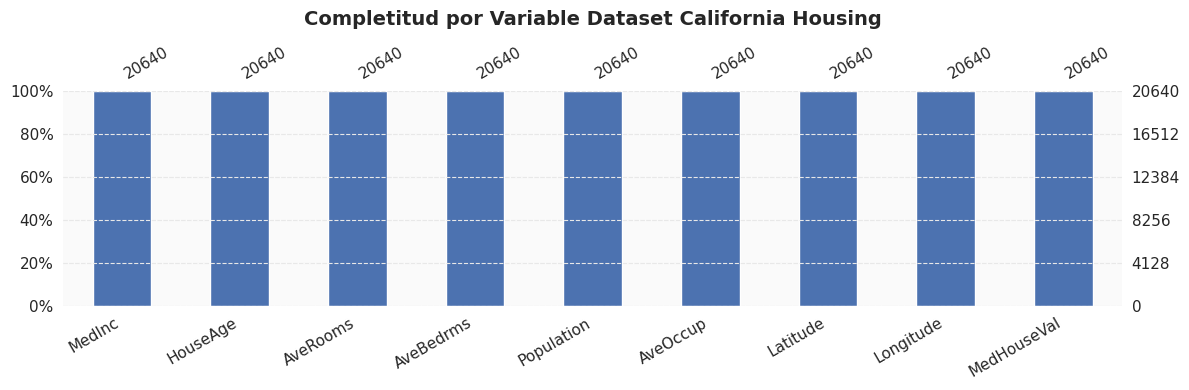

In [ ]:
# Barras de completitud
import matplotlib.ticker as mtick
fig, ax = plt.subplots(figsize=(12, 4))

msno.bar(
    df,
    ax=ax,
    color="#4C72B0",
    fontsize=11,
    label_rotation=30,
)
ax.set_title("Completitud por Variable Dataset California Housing",
            fontsize=14, fontweight="bold", pad=14)
ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1, decimals=0)
)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:309: UserWarning:

Attempting to set identical low and high xlims makes transformation singular; automatically expanding.

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:309: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.



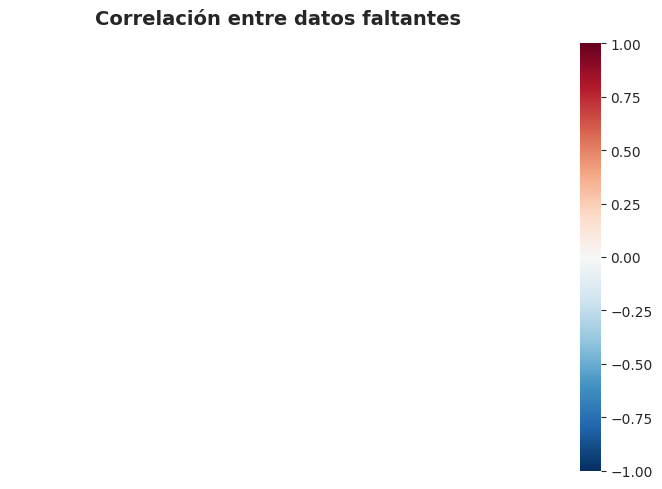

In [ ]:
# Mapa de calor relación entre datos faltantes
fig, ax = plt.subplots(figsize=(7, 5))

msno.heatmap(
    df,
    ax=ax,
    cmap="RdBu_r",        # divergente: rojo = correlación positiva
    fontsize=11,
    label_rotation=45,
)
ax.set_title("Correlación entre datos faltantes",
            fontsize=14, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

In [ ]:
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


In [ ]:
# Creamos variables categóricas derivadas para el análisis
df['PriceCategory'] = pd.qcut(
    df['MedHouseVal'],
    q=4,
    labels=['Bajo', 'Medio-bajo', 'Medio-alto', 'Alto']
).astype('category')

df['IncomeGroup'] = pd.qcut(
    df['MedInc'],
    q=3,
    labels=['Bajo', 'Medio', 'Alto']
).astype('category')

df['Region'] = pd.cut(
    df['Latitude'],
    bins=[32, 34.5, 37.5, 43],
    labels=['Sur', 'Centro', 'Norte']
).astype('category')

In [ ]:
# Tipos de datos con variables derivadas
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64
PriceCategory,category


# 2. Análisis descritivo de los datos

Se calculan las principales medidas de tendencia central, dispersión y forma para cada variable numérica del dataset. Estas métricas permiten caracterizar la distribución de cada variable e identificar posibles asimetrías, valores extremos o comportamientos atípicos antes de proceder al análisis inferencial.

In [ ]:
# Medidas de tendencia central
# Seleccionar solo columnas numéricas (excluimos Latitude y Longitude)
df_num = df.select_dtypes(include=["number"]).drop(columns=['Latitude', 'Longitude'])

print(f"Variables numéricas ({df_num.shape[1]}):", df_num.columns.tolist())

Variables numéricas (7): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal']


In [ ]:
from scipy import stats

def resumen_estadistico(df):
    num = df_num
    q1  = num.quantile(0.25)
    q3  = num.quantile(0.75)

    resumen = pd.DataFrame({
        # Tendencia central
        "media":       num.mean(),
        "mediana":     num.median(),
        "moda":        num.apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan),

        # Dispersión
        "desv_std":    num.std(),
        "varianza":    num.var(),
        "cv_%":        (num.std() / num.mean() * 100).round(2),

        # Rango
        "min":         num.min(),
        "max":         num.max(),
        "rango":       num.max() - num.min(),
        "IQR":         q3 - q1,

        # Percentiles
        "p25":         num.quantile(0.25),
        "p75":         num.quantile(0.75),

        # Forma de la distribución
        "asimetria":   num.skew(),
        "curtosis":    num.kurt(),

        # Calidad del dato
        "nulos":       num.isnull().sum(),
        "nulos_%":     (num.isnull().mean() * 100).round(2),
    })

    return resumen.round(4).T

resumen_estadistico(df)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,MedHouseVal
media,3.8707,28.6395,5.4290,1.0967,1.425477e+03,3.0707,2.0686
mediana,3.5348,29.0000,5.2291,1.0488,1.166000e+03,2.8181,1.7970
moda,3.1250,52.0000,5.0000,1.0000,8.910000e+02,3.0000,5.0000
desv_std,1.8998,12.5856,2.4742,0.4739,1.132462e+03,10.3860,1.1540
varianza,3.6093,158.3963,6.1215,0.2246,1.282470e+06,107.8700,1.3316
cv_%,49.0800,43.9400,45.5700,43.2100,7.944000e+01,338.2400,55.7900
min,0.4999,1.0000,0.8462,0.3333,3.000000e+00,0.6923,0.1500
max,15.0001,52.0000,141.9091,34.0667,3.568200e+04,1243.3333,5.0000
rango,14.5002,51.0000,141.0629,33.7333,3.567900e+04,1242.6410,4.8500
IQR,2.1798,19.0000,1.6117,0.0934,9.380000e+02,0.8525,1.4512


In [ ]:
df_num.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,5.000010


Para las variables de tipo objeto o categoría se analiza la distribución de frecuencias absolutas y relativas, el número de categorías únicas, la categoría modal y el grado de desbalance entre clases. Estas métricas son fundamentales para detectar clases dominantes, categorías raras o problemas de codificación antes del modelado.

In [ ]:
# Seleccionar columnas de tipo category (variables derivadas)
df_cat = df.select_dtypes(include=["category"])

print(f"Variables categóricas ({df_cat.shape[1]}):", df_cat.columns.tolist())

Variables categóricas (3): ['PriceCategory', 'IncomeGroup', 'Region']


In [ ]:
# Tabla resumen general
from scipy.stats import entropy

def resumen_categoricas(df):
    cat = df.select_dtypes(include=["object", "category", "bool"])
    filas = []

    for col in cat.columns:
        vc      = cat[col].value_counts(dropna=False)
        vc_rel  = cat[col].value_counts(normalize=True, dropna=False)
        n_uniq  = cat[col].nunique()
        moda    = cat[col].mode()[0] if not cat[col].mode().empty else np.nan
        freq_m  = vc_rel.iloc[0]          # frecuencia relativa de la moda
        nulos   = cat[col].isnull().sum()
        pct_n   = round(nulos / len(cat) * 100, 2)

        # Entropía de Shannon (diversidad de categorías)
        ent = entropy(vc_rel.values, base=2)

        # Ratio de desbalance: frec. moda / frec. categoría menos frecuente
        imbal = round(vc_rel.iloc[0] / vc_rel.iloc[-1], 2) if n_uniq > 1 else np.nan

        filas.append({
            "variable":        col,
            "n_categorias":    n_uniq,
            "moda":            moda,
            "frec_moda_%":     round(freq_m * 100, 2),
            "entropia_bits":   round(ent, 4),
            "desbalance_ratio":imbal,
            #"nulos":           nulos,
            #"nulos_%":         pct_n,
        })

    return pd.DataFrame(filas).set_index("variable")

resumen_categoricas(df)

,n_categorias,moda,frec_moda_%,entropia_bits,desbalance_ratio
variable,,,,,
PriceCategory,4,Bajo,25.01,2.0000,1.00
IncomeGroup,3,Medio,33.34,1.5850,1.00
Region,3,Sur,53.06,1.4423,3.08


# 3. Algunas visualizaciones

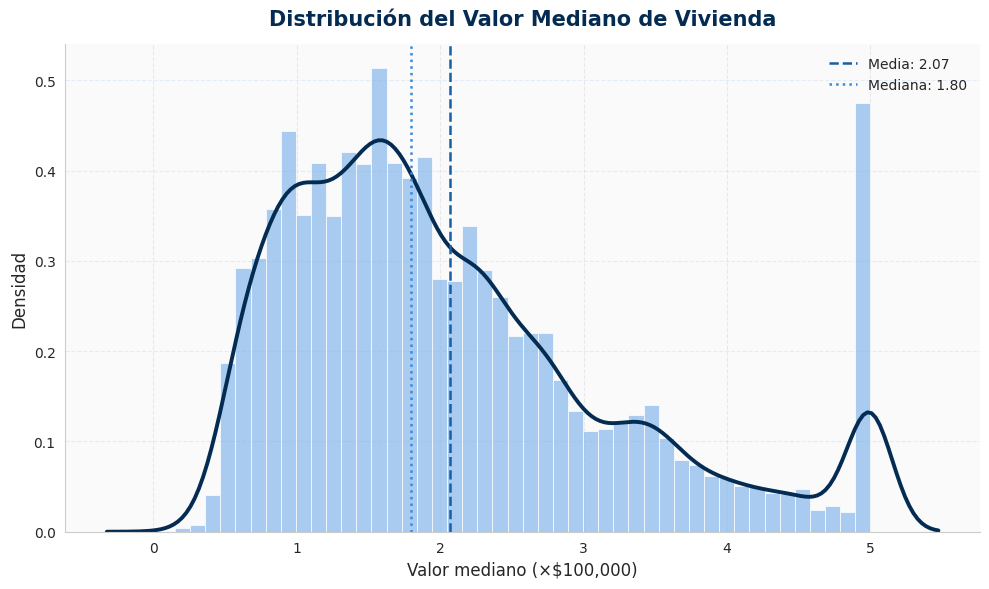

In [ ]:
# Distribución del valor mediano de las viviendas
media, mediana = df['MedHouseVal'].mean(), df['MedHouseVal'].median()
datos = df['MedHouseVal']

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['MedHouseVal'], stat="density", color="#85B7EB",
             edgecolor="white", linewidth=0.5, alpha=0.7, ax=ax)

# Curva KDE encima
sns.kdeplot(datos, color="#042C53", linewidth=2.8, ax=ax)

# Líneas de media y mediana
ax.axvline(media,   color="#185FA5", lw=1.8, ls="--", label=f"Media: {media:.2f}")
ax.axvline(mediana, color="#378ADD", lw=1.8, ls=":",  label=f"Mediana: {mediana:.2f}")

ax.set_title("Distribución del Valor Mediano de Vivienda",
             fontsize=15, fontweight="bold", pad=14, color="#042C53")
ax.set_xlabel("Valor mediano (×$100,000)", fontsize=12)
ax.set_ylabel("Densidad", fontsize=12)
ax.legend(fontsize=10, frameon=False)
sns.despine()
ax.yaxis.grid(True, linestyle="--", alpha=0.35, color="#B5D4F4")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_8395/4239141837.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


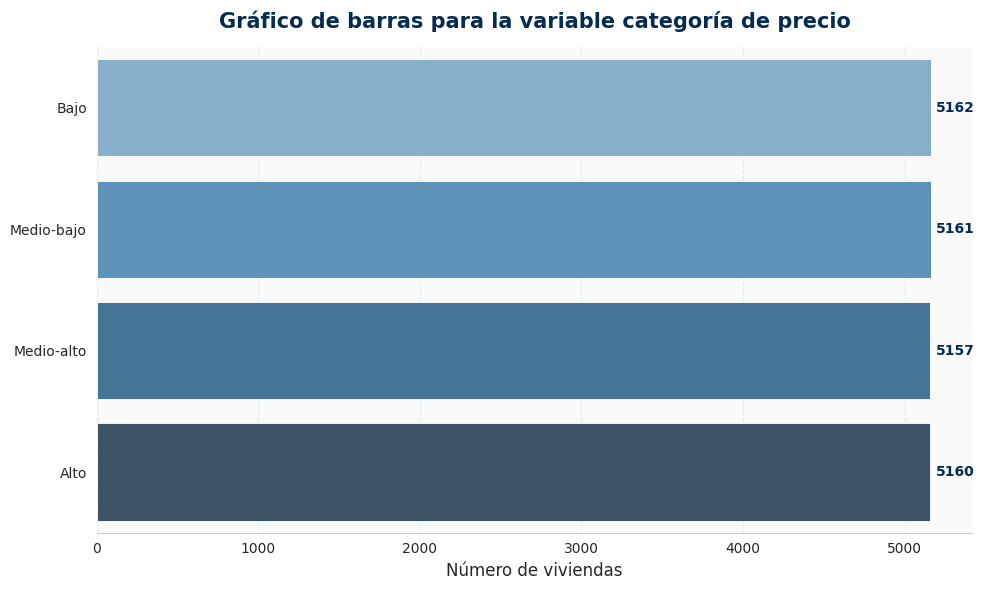

In [ ]:
price_counts_df = df['PriceCategory'].value_counts().reset_index()
price_counts_df.columns = ['Categoría', 'Viviendas']

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=price_counts_df,
    y="Categoría",
    x="Viviendas",
    palette="Blues_d",
    edgecolor="white",
    linewidth=0.6,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f", # sin decimales
        padding=4, # Separación del texto
        fontsize=10,
        color="#042C53",
        fontweight="bold"
    )

ax.set_title("Gráfico de barras para la variable categoría de precio",
             fontsize=15, fontweight="bold", pad=14, color="#042C53")
ax.set_xlabel("Número de viviendas", fontsize=12)
ax.set_ylabel("")
ax.tick_params(labelsize=10)
sns.despine(left=True, bottom=False) # Elimina línea izquierda (estilo más limpio tipo dashboard)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="#B5D4F4")
ax.set_axisbelow(True)

plt.tight_layout()
# plt.savefig("barras_horizontal.png", dpi=300, bbox_inches="tight")
plt.show()

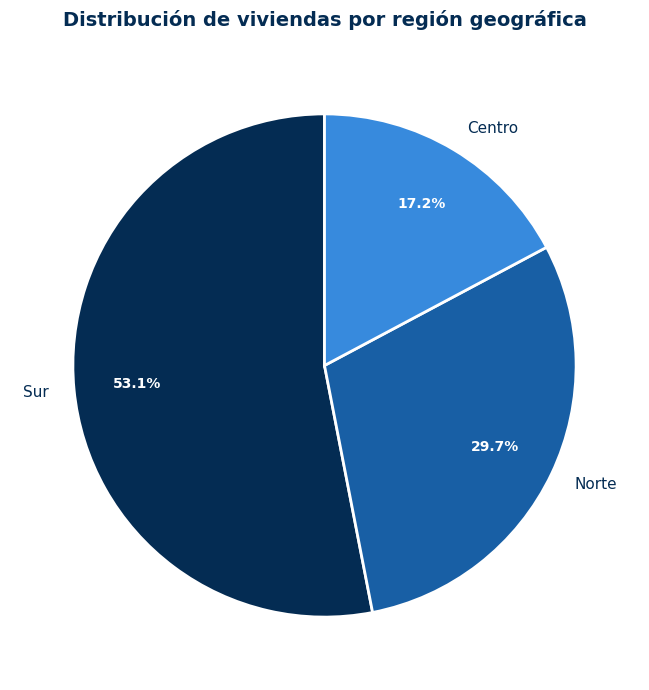

In [ ]:
region_counts_df = df['Region'].value_counts().reset_index() # reset.index() convierte a DataFrame
region_counts_df.columns = ['Categoría', 'Viviendas']

fig, ax = plt.subplots(figsize=(8, 7))
colores = ["#042C53", "#185FA5", "#378ADD", "#85B7EB", "#B5D4F4"]

valores = region_counts_df['Viviendas']
categorias = region_counts_df['Categoría']

wedges, texts, autotexts = ax.pie(
    valores,
    labels=categorias,
    colors=colores,
    autopct="%1.1f%%", # muestra porcentaje con 1 decimal
    startangle=90,
    pctdistance=0.75, # Posición del porcentaje dentro del círculo
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

# Personalizar porcentajes
for text in texts:
    text.set_fontsize(11)
    text.set_color("#042C53")
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color("white")
    autotext.set_fontweight("bold")
ax.set_title("Distribución de viviendas por región geográfica",
             fontsize=14, fontweight="bold", pad=18, color="#042C53")

plt.tight_layout() # Evita que elementos se encimen
#plt.savefig("pie_region.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Visualizaciones del análisis descriptivo — Variables numéricas

En esta sección se representan gráficamente las distribuciones de las variables numéricas del dataset con el objetivo de complementar las métricas calculadas en la sección anterior. Los boxplots comparativos por categoría de precio permiten identificar diferencias en la tendencia central, la dispersión y la presencia de valores atípicos entre los cuatro grupos de valor. El violin plot combina la forma de la distribución con la comparación por región geográfica y grupo de ingreso, revelando patrones que los boxplots no capturan. Finalmente, el mapa de calor de correlaciones cuantifica y visualiza las relaciones lineales entre variables cuantitativas, insumo indispensable para la selección de características en modelos predictivos.

/tmp/ipykernel_8395/3877960563.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8395/3877960563.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8395/3877960563.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8395/3877960563.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




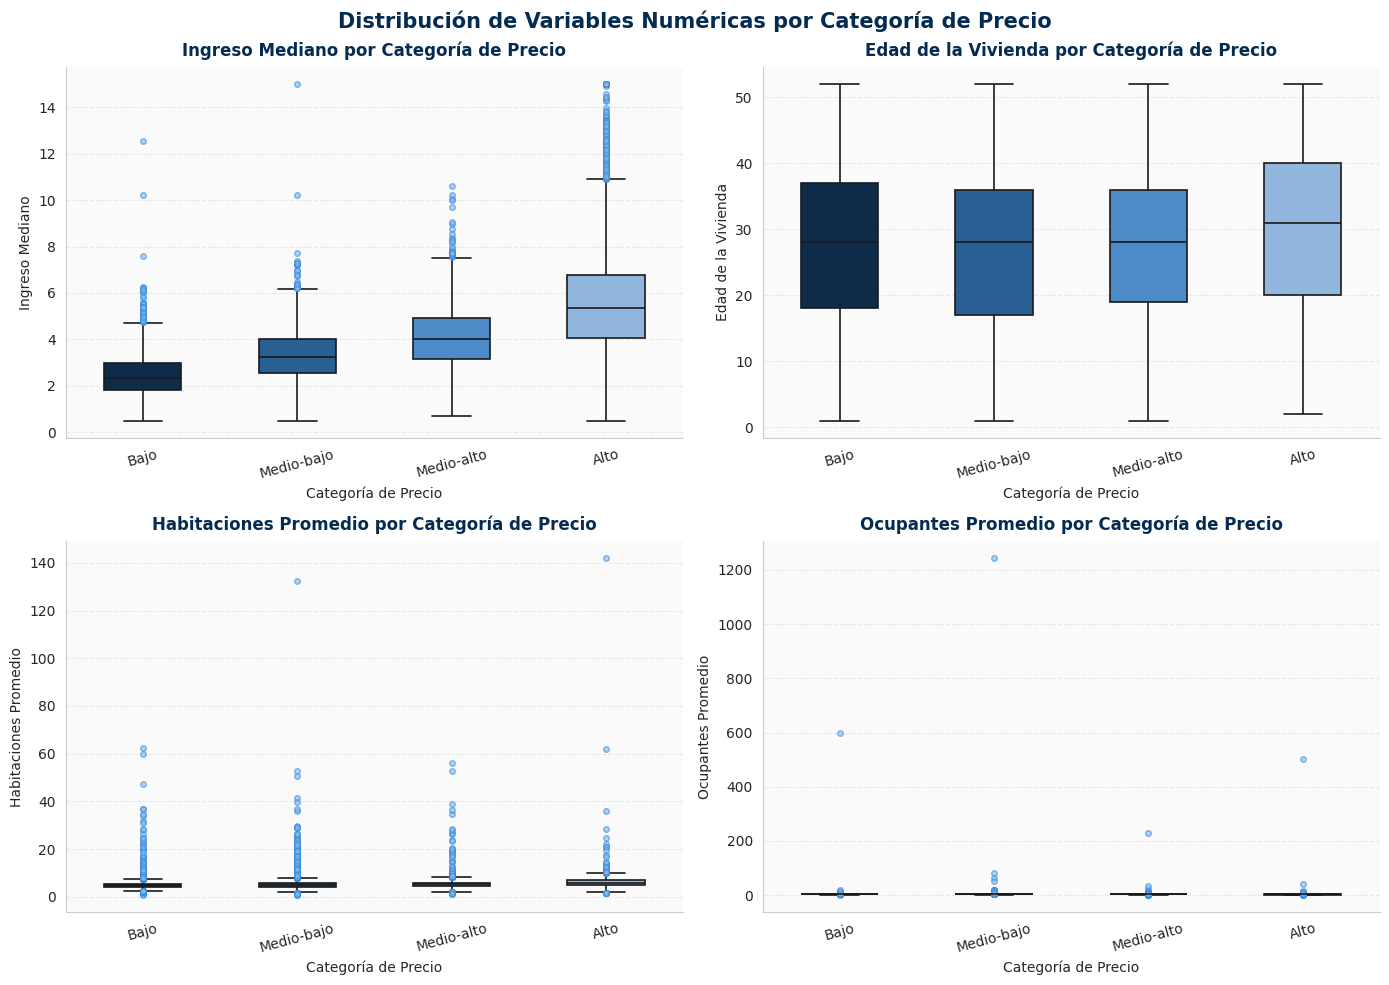

In [ ]:
# ── Paleta y etiquetas en español ────────────────────────────────────
paleta    = ['#042C53', '#185FA5', '#378ADD', '#85B7EB']
vars_num  = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
labels_es = {
    'MedInc':   'Ingreso Mediano',
    'HouseAge': 'Edad de la Vivienda',
    'AveRooms': 'Habitaciones Promedio',
    'AveOccup': 'Ocupantes Promedio',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(vars_num):
    ax = axes[i]

    # ── Boxplot por categoría de precio ─────────────────────────────────
    sns.boxplot(
        data=df, x='PriceCategory', y=var,
        palette=paleta[:4],
        width=0.5,
        flierprops=dict(
            marker='o', markersize=4,
            markerfacecolor='#85B7EB', markeredgecolor='#378ADD',
            alpha=0.6, linestyle='none',
        ),
        linewidth=1.2,
        ax=ax,
    )

    # ── Anotar número de outliers sobre cada caja ───────────────────────
   # for j, cat in enumerate(df['PriceCategory'].cat.categories):
   #     sub   = df[df['PriceCategory'] == cat][var].dropna()
   #     q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
   #     iqr    = q3 - q1
   #     n_out  = int(((sub < q1 - 1.5 * iqr) | (sub > q3 + 1.5 * iqr)).sum())
   #     if n_out > 0:
   #         ax.text(
   #             j, ax.get_ylim()[1] * 0.97,
   #             f'atíp.: {n_out}',
   #             ha='center', va='top',
   #             fontsize=8, color='#042C53', fontstyle='italic',
   #         )

    ax.set_title(
        f"{labels_es[var]} por Categoría de Precio",
        fontsize=12, fontweight='bold', color='#042C53', pad=8,
    )
    ax.set_xlabel('Categoría de Precio', fontsize=10)
    ax.set_ylabel(labels_es[var], fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    sns.despine(ax=ax)

fig.suptitle(
    'Distribución de Variables Numéricas por Categoría de Precio',
    fontsize=15, fontweight='bold', color='#042C53',
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8395/3911654411.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_8395/3911654411.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_8395/3911654411.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


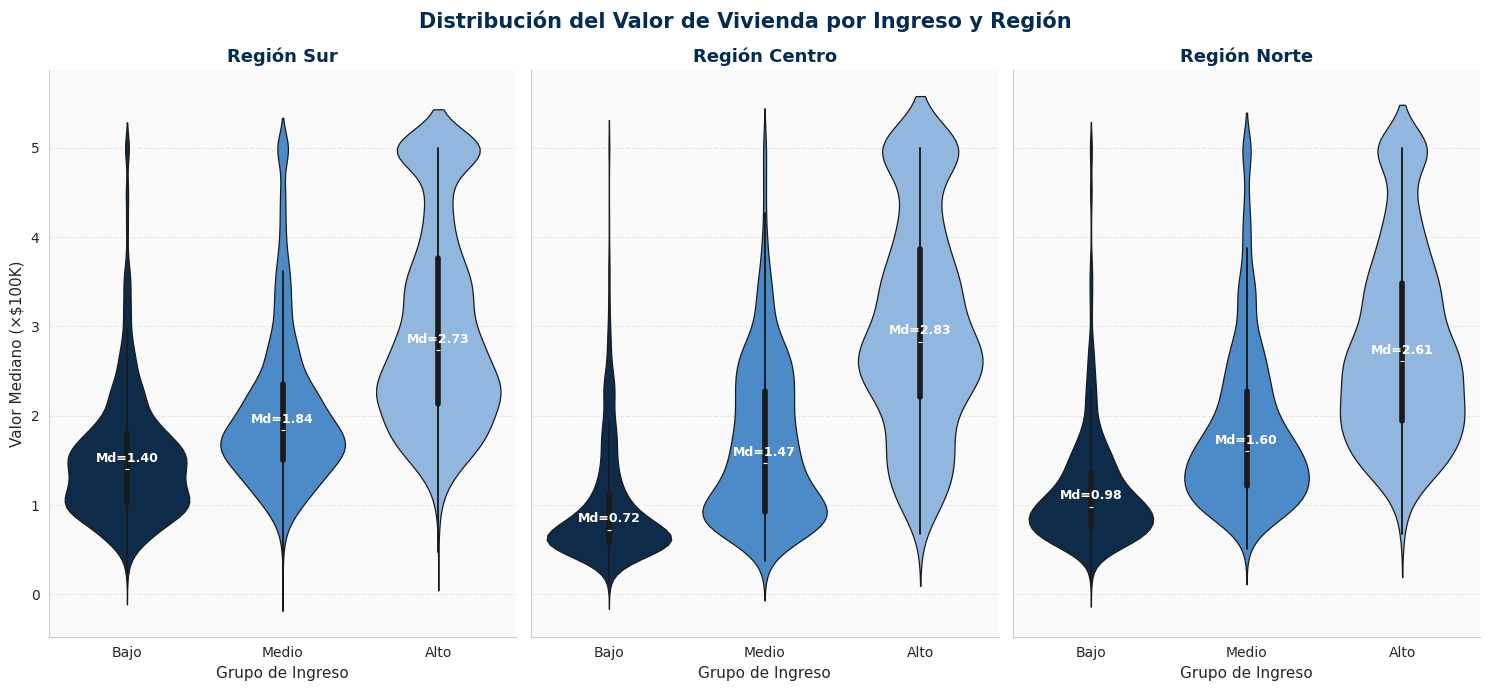

In [ ]:
# ── Violin plot: valor de vivienda por grupo de ingreso, un panel por región ─
regiones = df['Region'].cat.categories.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=True)

for ax, region in zip(axes, regiones):
    data_r = df[df['Region'] == region]

    sns.violinplot(
        data=data_r,
        x='IncomeGroup',
        y='MedHouseVal',
        palette={'Bajo': '#042C53', 'Medio': '#378ADD', 'Alto': '#85B7EB'},
        inner='box',
        linewidth=0.9,
        ax=ax,
    )

    # ── Medianas anotadas ────────────────────────────────────────────────────
    for j, grupo in enumerate(['Bajo', 'Medio', 'Alto']):
        subset = data_r[data_r['IncomeGroup'] == grupo]['MedHouseVal']
        if len(subset) > 0:
            med = subset.median()
            ax.text(
                j, med + 0.05,
                f'Md={med:.2f}',
                ha='center', va='bottom',
                fontsize=9, color='white', fontweight='bold',
            )

    ax.set_title(f'Región {region}', fontsize=13, fontweight='bold', color='#042C53')
    ax.set_xlabel('Grupo de Ingreso', fontsize=11)
    ax.set_ylabel('Valor Mediano (×$100K)' if region == regiones[0] else '', fontsize=11)
    sns.despine(ax=ax)

fig.suptitle(
    'Distribución del Valor de Vivienda por Ingreso y Región',
    fontsize=15, fontweight='bold', color='#042C53',
)
plt.tight_layout()
plt.show()

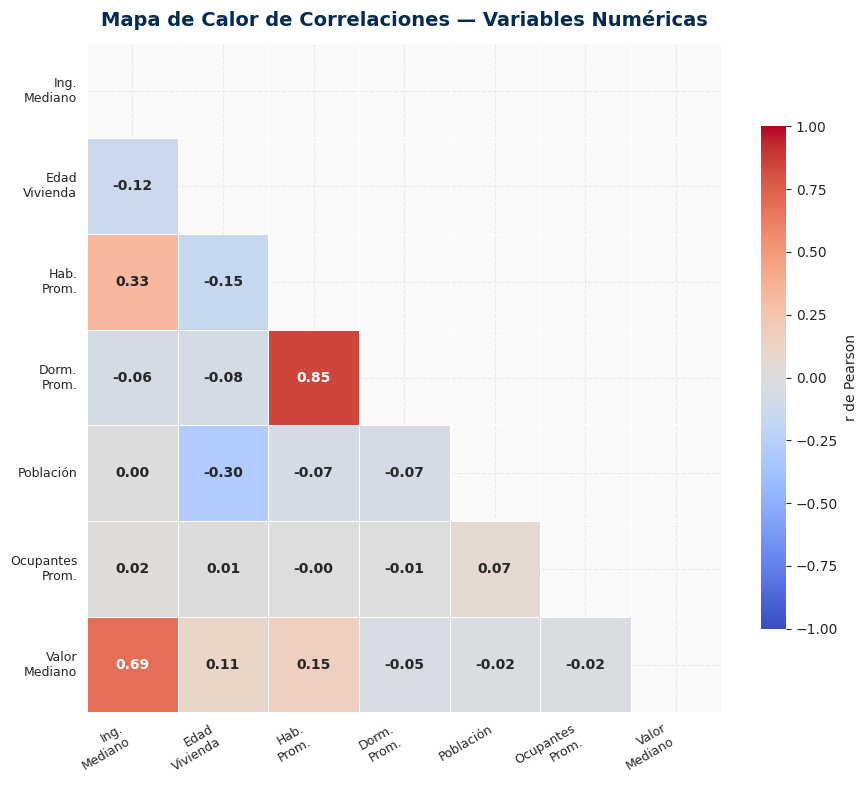

In [ ]:
# ── Heatmap de correlaciones (triángulo inferior) ─────────────────────────
corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # máscara triangular superior

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor='#FFFFFF',
    annot_kws={'size': 10, 'weight': 'bold'},
    cbar_kws={'shrink': 0.75, 'label': 'r de Pearson'},
    ax=ax,
)

etiquetas = ['Ing.\nMediano', 'Edad\nVivienda', 'Hab.\nProm.', 'Dorm.\nProm.',
             'Población', 'Ocupantes\nProm.', 'Valor\nMediano']
ax.set_xticklabels(etiquetas, fontsize=9, rotation=30, ha='right')
ax.set_yticklabels(etiquetas, fontsize=9, rotation=0)
ax.set_title(
    'Mapa de Calor de Correlaciones — Variables Numéricas',
    fontsize=14, fontweight='bold', color='#042C53', pad=12,
)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 5. Visualizaciones del análisis descriptivo — Variables categóricas

Las visualizaciones de variables categóricas derivadas revelan la composición geográfica del dataset y las diferencias en el valor de las viviendas según distintos factores socioeconómicos y de ubicación. El gráfico de barras apiladas contrasta la distribución de categorías de precio entre regiones geográficas, mostrando frecuencias absolutas y relativas en cada segmento. El barplot agrupado cuantifica el valor mediano promedio por combinación de región e ingreso, mientras que el treemap interactivo ofrece una visión proporcional de la distribución de viviendas según la región y la categoría de precio, facilitando identificar el perfil más frecuente.

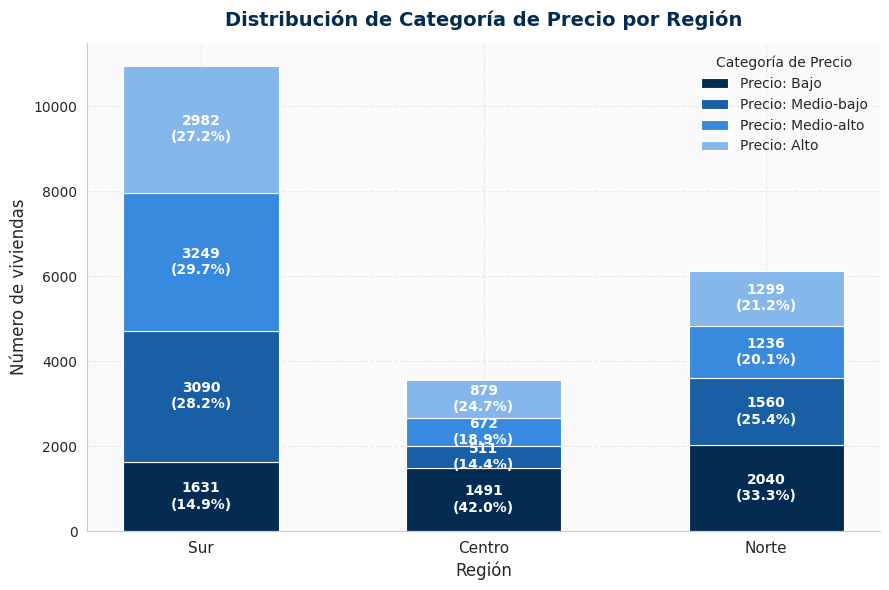

In [ ]:
# ── Tabla de contingencia: categoría de precio × región ───────────────────────────────
ct     = pd.crosstab(df['Region'], df['PriceCategory'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 6))
colores_price = {
    'Bajo':       '#042C53',
    'Medio-bajo': '#185FA5',
    'Medio-alto': '#378ADD',
    'Alto':       '#85B7EB',
}
bottom = np.zeros(len(ct))

for col in ct.columns:
    valores = ct[col].values.astype(float)
    ax.bar(
        range(len(ct.index)),
        valores,
        bottom=bottom,
        color=colores_price[col],
        label=f'Precio: {col}',
        edgecolor='white',
        linewidth=0.8,
        width=0.55,
    )
    for k, (v, b) in enumerate(zip(valores, bottom)):
        pct = ct_pct[col].iloc[k]
        if v > 100:
            ax.text(
                k, b + v / 2,
                f'{int(v)}\n({pct:.1f}%)',
                ha='center', va='center',
                fontsize=10, color='white', fontweight='bold',
            )
    bottom += valores

ax.set_title(
    'Distribución de Categoría de Precio por Región',
    fontsize=14, fontweight='bold', color='#042C53', pad=12,
)
ax.set_xlabel('Región', fontsize=12)
ax.set_ylabel('Número de viviendas', fontsize=12)
ax.set_xticks(range(len(ct.index)))
ax.set_xticklabels(ct.index.tolist(), fontsize=11)
ax.legend(title='Categoría de Precio', frameon=False, fontsize=10, title_fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

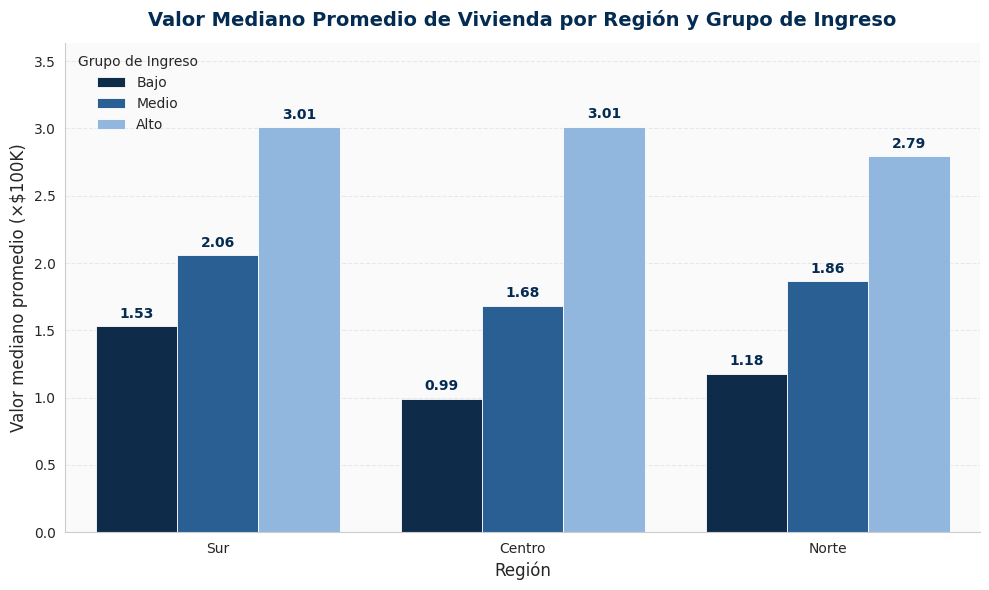

In [ ]:
# ── Valor mediano promedio por región y grupo de ingreso ────────────────────────────────
valor_medio = (
    df.groupby(['Region', 'IncomeGroup'], observed=True)['MedHouseVal']
      .mean()
      .reset_index()
      .rename(columns={'MedHouseVal': 'valor_medio'})
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=valor_medio,
    x='Region',
    y='valor_medio',
    hue='IncomeGroup',
    palette={'Bajo': '#042C53', 'Medio': '#185FA5', 'Alto': '#85B7EB'},
    edgecolor='white',
    linewidth=0.6,
    ax=ax,
)

for container in ax.containers:
    labels = [f'{v.get_height():.2f}' for v in container]
    ax.bar_label(
        container, labels=labels,
        padding=4, fontsize=10, color='#042C53', fontweight='bold',
    )

ax.set_title(
    'Valor Mediano Promedio de Vivienda por Región y Grupo de Ingreso',
    fontsize=14, fontweight='bold', color='#042C53', pad=12,
)
ax.set_xlabel('Región', fontsize=12)
ax.set_ylabel('Valor mediano promedio (×$100K)', fontsize=12)
ax.legend(title='Grupo de Ingreso', frameon=False, fontsize=10, title_fontsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# ── Preparar datos: distribución Region × PriceCategory ───────────────────────────
df_tree = (
    df.dropna(subset=['Region', 'PriceCategory'])
      .groupby(['Region', 'PriceCategory'], observed=True)
      .size()
      .reset_index(name='conteo')
)
df_tree['region_str'] = df_tree['Region'].astype(str)
df_tree['price_str']  = df_tree['PriceCategory'].astype(str)

# ── Treemap interactivo ───────────────────────────────────────────────────
fig_tree = px.treemap(
    df_tree,
    path=['region_str', 'price_str'],
    values='conteo',
    color='conteo',
    color_continuous_scale=['#85B7EB', '#378ADD', '#185FA5', '#042C53'],
    title='Distribución de Viviendas: Región × Categoría de Precio',
)
fig_tree.update_traces(
    textinfo='label+value+percent parent',
    textfont_size=13,
    marker_line_color='white',
    marker_line_width=1.5,
)
fig_tree.update_layout(
    title_font=dict(size=16, color='#042C53'),
    margin=dict(t=60, l=10, r=10, b=10),
    coloraxis_showscale=False,
)
fig_tree.show()

# 6. Relaciones bivariadas

El análisis bivariado examina cómo cada variable se relaciona con el valor mediano de las viviendas y con las demás covariables. El pairplot ofrece una vista panorámica de todas las combinaciones de variables numéricas clave coloreadas por categoría de precio, detectando patrones de separación entre grupos. Las pruebas ANOVA de un factor formalizan la asociación entre el valor de la vivienda y cada variable categórica derivada, indicando si las diferencias observadas entre grupos son estadísticamente significativas. Los pointplots con intervalos de confianza al 95% permiten comparar el ingreso mediano y la edad de la vivienda por categoría de precio, ofreciendo una estimación de la incertidumbre asociada a cada grupo.

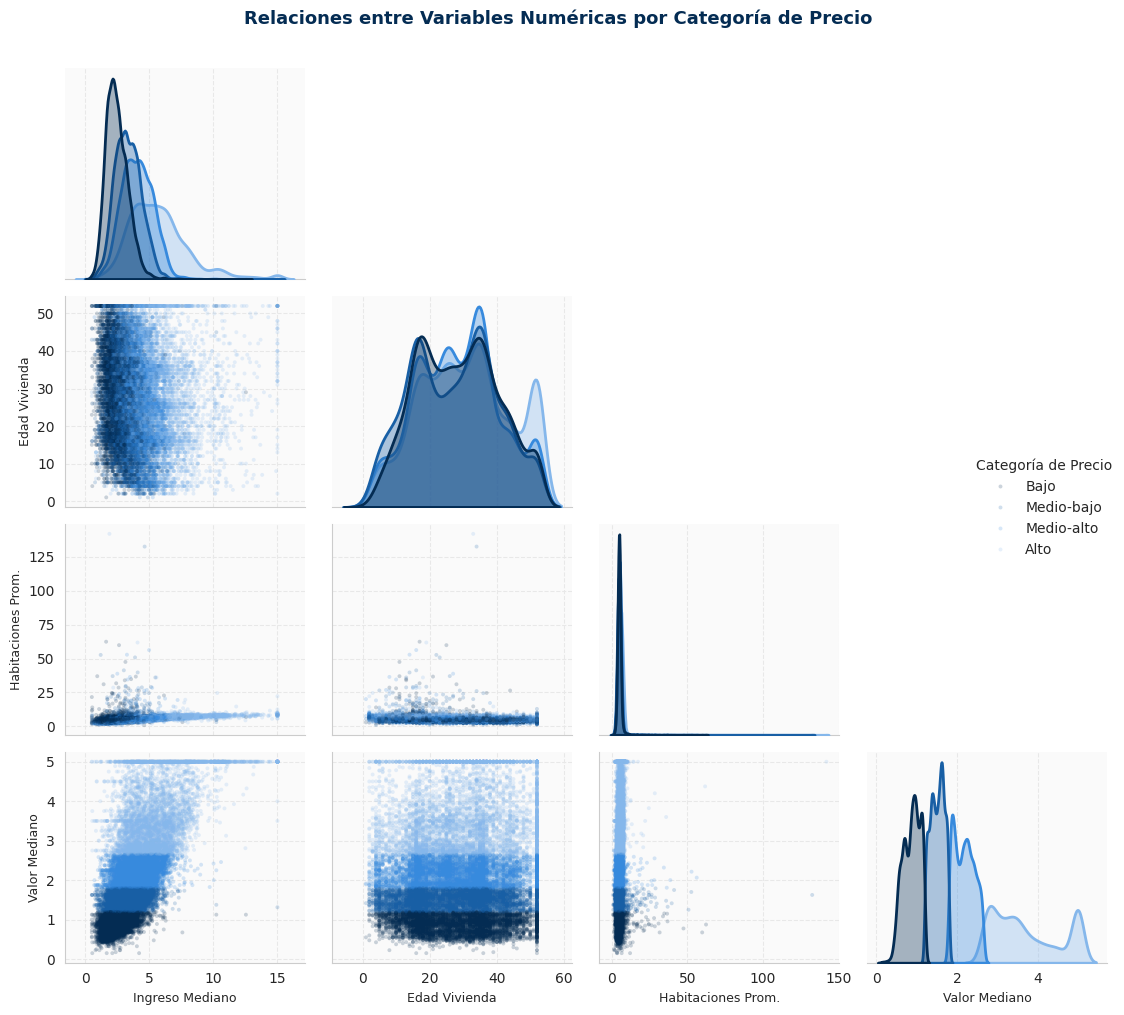

In [ ]:
# ── Pairplot de variables numéricas coloreado por categoría de precio ────────────
vars_pair = ['MedInc', 'HouseAge', 'AveRooms', 'MedHouseVal']
df_pair   = df[vars_pair + ['PriceCategory']].dropna(subset=vars_pair)

g = sns.pairplot(
    df_pair,
    hue='PriceCategory',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.2, 'edgecolor': 'none', 's': 8},
    diag_kws={'linewidth': 2.0, 'fill': True, 'alpha': 0.35},
    palette={
        'Bajo':       '#042C53',
        'Medio-bajo': '#185FA5',
        'Medio-alto': '#378ADD',
        'Alto':       '#85B7EB',
    },
)

# ── Renombrar ejes ────────────────────────────────────────────────────────
ren = {
    'MedInc':     'Ingreso Mediano',
    'HouseAge':   'Edad Vivienda',
    'AveRooms':   'Habitaciones Prom.',
    'MedHouseVal':'Valor Mediano',
}
for ax in g.axes.flatten():
    if ax is not None:
        if ax.get_xlabel() in ren:
            ax.set_xlabel(ren[ax.get_xlabel()], fontsize=9)
        if ax.get_ylabel() in ren:
            ax.set_ylabel(ren[ax.get_ylabel()], fontsize=9)

g.figure.suptitle(
    'Relaciones entre Variables Numéricas por Categoría de Precio',
    fontsize=13, fontweight='bold', color='#042C53', y=1.01,
)
try:
    g._legend.set_title('Categoría de Precio')
    g._legend.get_frame().set_visible(False)
except Exception:
    pass

plt.tight_layout()
plt.show()

In [ ]:
# ── ANOVA de un factor: MedHouseVal vs. variables categóricas ───────────────
from scipy.stats import f_oneway

vars_cat_anova = ['PriceCategory', 'IncomeGroup', 'Region']
target = 'MedHouseVal'

resultados = []
for var in vars_cat_anova:
    grupos = [
        df[df[var] == cat][target].dropna()
        for cat in df[var].cat.categories
    ]
    f_stat, p_val = f_oneway(*grupos)

    # Eta cuadrado (tamaño del efecto)
    grand_mean = df[target].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in grupos)
    ss_total   = sum((df[target] - grand_mean)**2)
    eta2       = round(ss_between / ss_total, 4)

    resultados.append({
        'variable':      var,
        'F':             round(f_stat, 3),
        'p_value':       round(p_val, 6),
        'eta²':          eta2,
        'significativo': '✓ Sí' if p_val < 0.05 else '✗ No',
    })

tabla_anova = (
    pd.DataFrame(resultados)
      .set_index('variable')
      .sort_values('p_value')
)

print(f'ANOVA de un factor | Variable dependiente: {target}')
print('H₀: la media del valor de vivienda es igual en todos los grupos')
print('α = 0.05   •   η²: efecto pequeño < 0.06 | medio 0.06–0.14 | grande > 0.14')
print('─' * 65)
tabla_anova

ANOVA de un factor | Variable dependiente: MedHouseVal
H₀: la media del valor de vivienda es igual en todos los grupos
α = 0.05   •   η²: efecto pequeño < 0.06 | medio 0.06–0.14 | grande > 0.14
─────────────────────────────────────────────────────────────────


,F,p_value,eta²,significativo
variable,,,,
PriceCategory,38787.413,0.0,0.8494,✓ Sí
IncomeGroup,5388.919,0.0,0.3431,✓ Sí
Region,254.686,0.0,0.0241,✓ Sí


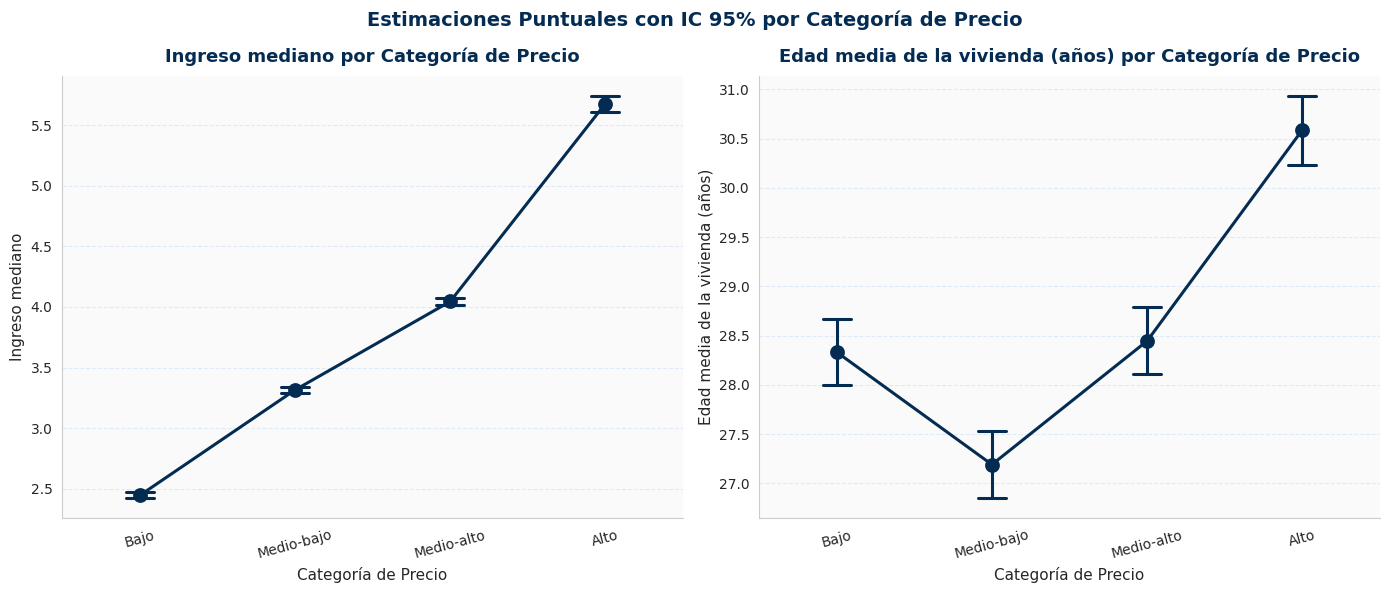

In [ ]:
# ── Pointplot: medias de MedInc y HouseAge por categoría de precio con IC 95% ─
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

config = [
    ('MedInc',   'Ingreso mediano'),
    ('HouseAge', 'Edad media de la vivienda (años)'),
]

for ax, (var, ylabel) in zip(axes, config):
    sns.pointplot(
        data=df,
        x='PriceCategory',
        y=var,
        errorbar=('ci', 95),
        capsize=0.18,
        color='#042C53',
        linewidth=2.2,
        markersize=9,
        ax=ax,
    )
    ax.set_title(
        f'{ylabel} por Categoría de Precio',
        fontsize=13, fontweight='bold', color='#042C53', pad=10,
    )
    ax.set_xlabel('Categoría de Precio', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#B5D4F4')
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

fig.suptitle(
    'Estimaciones Puntuales con IC 95% por Categoría de Precio',
    fontsize=14, fontweight='bold', color='#042C53',
)
plt.tight_layout()
plt.show()

# 7. Análisis de outliers

Los valores atípicos pueden distorsionar medidas de tendencia central, inflar la varianza e introducir sesgo en modelos estadísticos y de aprendizaje automático. En esta sección se identifican los outliers de las variables `MedHouseVal` y `MedInc` mediante el método IQR (límites en Q1 − 1.5·IQR y Q3 + 1.5·IQR), reconocido por su robustez frente a distribuciones asimétricas. Adicionalmente, se compara la distribución del valor mediano de la vivienda antes y después de aplicar winsorización al percentil 5–95, técnica que atenúa el efecto de los extremos sin eliminar observaciones del dataset. La decisión final sobre el tratamiento de cada variable se fundamenta en el contexto real de los datos.

In [ ]:
# ── Detección de outliers: método IQR ───────────────────────────────────────
def detectar_outliers_iqr(series):
    serie   = series.dropna()
    q1, q3  = serie.quantile(0.25), serie.quantile(0.75)
    iqr     = q3 - q1
    lb, ub  = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask    = (serie < lb) | (serie > ub)
    return pd.Series({
        'Q1':               round(q1, 2),
        'Q3':               round(q3, 2),
        'IQR':              round(iqr, 2),
        'lím. inferior':    round(lb, 2),
        'lím. superior':    round(ub, 2),
        'n_outliers':       int(mask.sum()),
        '% outliers':       round(mask.mean() * 100, 2),
        'min observado':    round(serie.min(), 2),
        'max observado':    round(serie.max(), 2),
    })

vars_out  = ['MedHouseVal', 'MedInc']
tabla_out = pd.DataFrame(
    {var: detectar_outliers_iqr(df[var]) for var in vars_out}
).T

print('Tabla de outliers — Método IQR (factor ×1.5)')
print('─' * 50)
tabla_out

Tabla de outliers — Método IQR (factor ×1.5)
──────────────────────────────────────────────────


,Q1,Q3,IQR,lím. inferior,lím. superior,n_outliers,% outliers,min observado,max observado
MedHouseVal,1.20,2.65,1.45,-0.98,4.82,1071.0,5.19,0.15,5.0
MedInc,2.56,4.74,2.18,-0.71,8.01,681.0,3.30,0.50,15.0


                Original  Winsorizada
Media              2.069        2.069
Desv. estándar     1.154        1.135
Mínimo             0.150        0.662
Máximo             5.000        4.898
Asimetría          0.978        0.967 



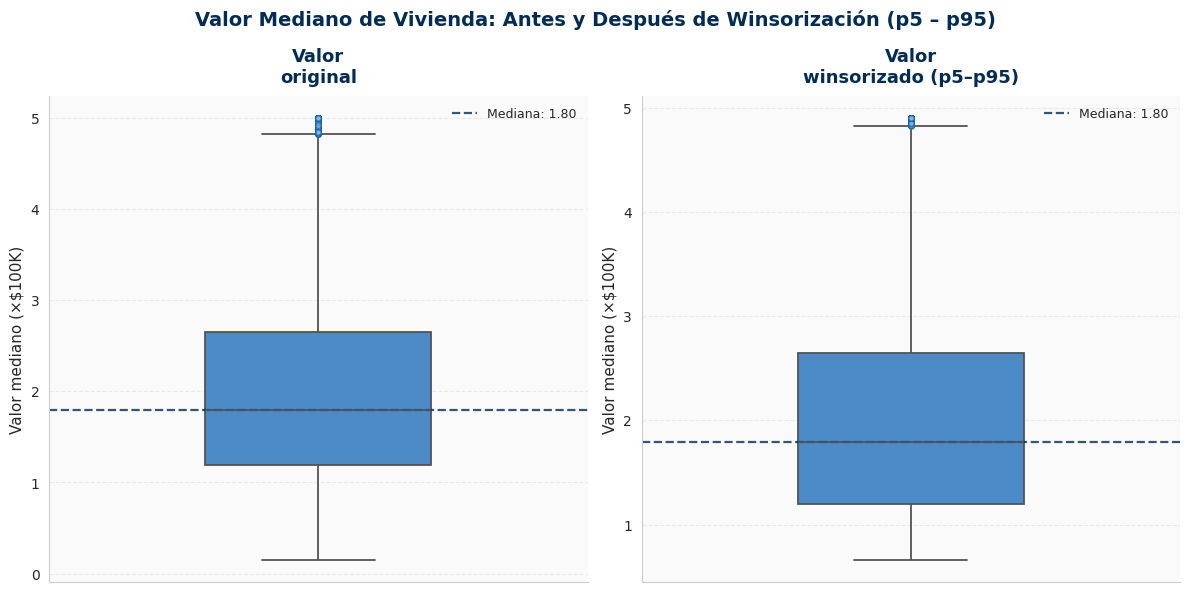

In [ ]:
from scipy.stats.mstats import winsorize

# ── Winsorización al p5 – p95 ──────────────────────────────────────────────────
val_orig = df['MedHouseVal'].dropna()
val_wins = pd.Series(
    winsorize(val_orig, limits=[0.05, 0.05]),
    index=val_orig.index,
    name='MedHouseVal_wins',
)

# ── Tabla comparativa de estadísticas ────────────────────────────────────
comp = pd.DataFrame({
    'Original':    [val_orig.mean(), val_orig.std(),
                    val_orig.min(), val_orig.max(), val_orig.skew()],
    'Winsorizada': [val_wins.mean(), val_wins.std(),
                    val_wins.min(), val_wins.max(), val_wins.skew()],
}, index=['Media', 'Desv. estándar', 'Mínimo', 'Máximo', 'Asimetría']).round(3)
print(comp.to_string(), '\n')

# ── Boxplot doble: antes y después ───────────────────────────────────────
df_box = pd.DataFrame({
    'Valor\noriginal':                val_orig,
    'Valor\nwinsorizado (p5–p95)':    val_wins,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, col in zip(axes, df_box.columns):
    sns.boxplot(
        y=df_box[col],
        color='#378ADD',
        flierprops=dict(
            marker='o', markersize=4,
            markerfacecolor='#85B7EB', markeredgecolor='#185FA5',
            alpha=0.55, linestyle='none',
        ),
        linewidth=1.3,
        width=0.42,
        ax=ax,
    )
    med = df_box[col].median()
    ax.axhline(med, color='#042C53', lw=1.6, ls='--', alpha=0.8,
               label=f'Mediana: {med:.2f}')
    ax.set_title(col, fontsize=13, fontweight='bold', color='#042C53', pad=10)
    ax.set_ylabel('Valor mediano (×$100K)', fontsize=11)
    ax.set_xlabel('')
    ax.legend(frameon=False, fontsize=9, loc='upper right')
    sns.despine(ax=ax)

fig.suptitle(
    'Valor Mediano de Vivienda: Antes y Después de Winsorización (p5 – p95)',
    fontsize=14, fontweight='bold', color='#042C53',
)
plt.tight_layout()
plt.show()

## ¿Qué hacer con los outliers en California Housing?

Antes de decidir el tratamiento, es fundamental recordar que **un valor atípico no es necesariamente un error**: puede ser una observación legítima, extrema pero real.

### `MedHouseVal` — Transformar o winsorizar para modelado
El valor mediano de las viviendas presenta una distribución asimétrica positiva y además está **truncado artificialmente en $500,000** (5.0 en unidades de ×$100K), lo que introduce una censura que puede afectar modelos de regresión. Los valores extremos reflejan diferencias reales entre zonas de lujo (Malibu, Beverly Hills) y áreas rurales. Para modelos sensibles a la escala se recomienda:

| Estrategia | Cuándo usarla |
|---|---|
| `np.log1p(MedHouseVal)` | Análisis descriptivo y modelos lineales |
| Winsorización p5–p95 | Modelos sensibles a extremos puntuales |
| `RobustScaler` | Preprocesamiento general en pipelines de sklearn |
| Conservar sin cambios | Árboles / Random Forest (no afectados por escala) |

### `MedInc` — Conservar con posible transformación
El ingreso mediano también presenta valores extremos pero legítimos: reflejan diferencias reales de nivel socioeconómico entre distritos. Se recomienda aplicar `RobustScaler` o una transformación logarítmica para modelos lineales, pero conservar sin cambios para árboles de decisión.

> **Regla general:** los outliers solo deben **eliminarse** si existe evidencia explícita de error en la recopilación de datos. En ausencia de dicha evidencia, la opción correcta es **documentarlos, transformarlos con criterio** y evaluar su impacto en las métricas del modelo.